# 🧠🤖 Atividade - Regressão de Seno com Descida do Gradiente

O objetivo da atividade é utilizar o algoritmo de descida do gradiente para realizar regressão de uma função seno, isto é, encontrar uma versão da função seno que mais se ajusta a um conjunto de pontos. Considere o seguinte conjunto de pontos:

In [1]:
import numpy as np

def ler_dados(path):
    with open(path, "r") as f:
        data = [line.split() for line in f.readlines()]
    data = np.array(data, dtype=np.float32)

    x = data[:, 0]
    y = data[:, 1]

    return x, y

x, y = ler_dados("data-1.txt")
x, y

(array([-10. ,  -9.5,  -9. ,  -8.5,  -8. ,  -7.5,  -7. ,  -6.5,  -6. ,
         -5.5,  -5. ,  -4.5,  -4. ,  -3.5,  -3. ,  -2.5,  -2. ,  -1.5,
         -1. ,  -0.5,   0. ,   0.5,   1. ,   1.5,   2. ,   2.5,   3. ,
          3.5,   4. ,   4.5,   5. ,   5.5,   6. ,   6.5,   7. ,   7.5,
          8. ,   8.5,   9. ,   9.5], dtype=float32),
 array([-3.049163  , -2.6773899 , -2.6716516 , -2.0710213 , -1.50771   ,
        -1.1924514 , -0.8683805 , -0.96150565, -1.2023299 , -1.8061168 ,
        -2.501456  , -3.0539794 , -3.2620528 , -3.1245124 , -2.9112937 ,
        -2.2453938 , -2.3087683 , -1.2598307 , -1.0636746 , -0.92266905,
        -0.8786576 , -1.729784  , -2.0099556 , -2.7642746 , -3.3521018 ,
        -3.3026602 , -3.272684  , -2.5428126 , -2.0814285 , -1.5314364 ,
        -1.2280508 , -0.8279353 , -1.1286899 , -1.5215187 , -1.8100852 ,
        -2.271931  , -2.940685  , -2.8459418 , -3.323826  , -2.8045368 ],
       dtype=float32))

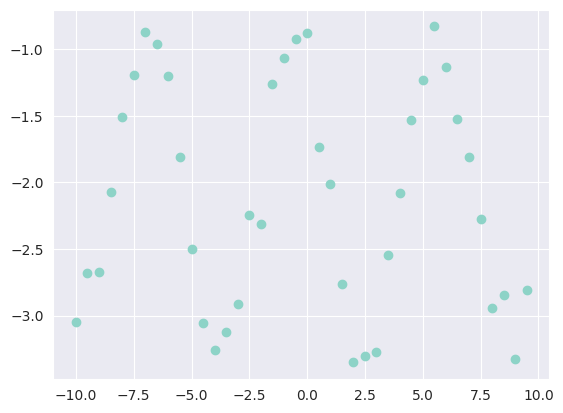

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

plt.plot(x, y, 'o')

Dada a função $f(x) = \sin(x + a) + b$, queremos encontrar os valores dos coeficientes $a$ e $b$ que minimizem o erro médio quadrático em relação aos pontos acima:

$$
loss = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - f(x_i) \right) ^2 = \frac{1}{n} \sum_{i=1}^{n} \left( y_i - \sin(a + x) - b) \right) ^2
$$

---

# Tarefas

## Implementação com Pytorch

### Tarefa: Use pytorch e as funções acima para implementar o algoritmo de descida do gradiente. Lembre-se de usar as funções do pytorch nas implementações (e.g., `torch.sin`, `torch.square`, `torch.mean`, etc.).

In [6]:
# resposta

import torch

def calcula_funcao(a, b, x):
    return torch.sin(a+x) + b

def loss_fn(y_real, y_predito):
    return torch.mean(torch.square(y_real-y_predito))

def gradient_descent_torch(x, y, n_epochs, lr):
    # inicializa coeficientes com valores aleatórios
    a = torch.tensor(np.random.uniform(-5, 5), dtype=torch.float32, requires_grad=True)
    b = torch.tensor(np.random.uniform(-5, 5), dtype=torch.float32, requires_grad=True)

    # transforma o dataset em tensores
    x = torch.from_numpy(x)
    y = torch.from_numpy(y)

    # salva o valor da perda e dos parametros antes de comecar o treinamento
    y_prd = calcula_funcao(a, b, x)
    history = [{"loss": loss_fn(y, y_prd).item(), "params": [a.item(), b.item()]}]

    # itera por varias epocas
    for _ in range(n_epochs):
        y_prd = calcula_funcao(a, b, x)
        loss = loss_fn(y, y_prd)

        # calcula a derivada parcial do erro em relação aos parâmetros
        loss.backward()

        # atualiza os valores dos parâmetros usando descida do gradiente
        with torch.no_grad():
            a -= lr*a.grad
            b -= lr*b.grad

        # reseta os gradientes para zero
        a.grad.zero_()
        b.grad.zero_()

        # salva o valor da loss e os valores dos coeficientes nesta época
        y_prd = calcula_funcao(a, b, x)
        loss = loss_fn(y, y_prd)
        history.append({"loss": loss.item(), "params": [a.item(), b.item()]})

    return history

history = gradient_descent_torch(x, y, 20, 1e-1)
for epoch in history:
    print(epoch['loss'])

2.210050582885742
1.4666420221328735
0.9822407960891724
0.6654657125473022
0.4574553072452545
0.3202216923236847
0.22919444739818573
0.16844558715820312
0.12762215733528137
0.09997551143169403
0.08109156787395477
0.06807229667901993
0.059006642550230026
0.05262783169746399
0.048091135919094086
0.04482964426279068
0.04245990514755249
0.04072052985429764
0.0394313707947731
0.038467444479465485
0.0377407930791378


A célula abaixo mostra a evolução da função de perda e a função antes e depois do treinamento. 

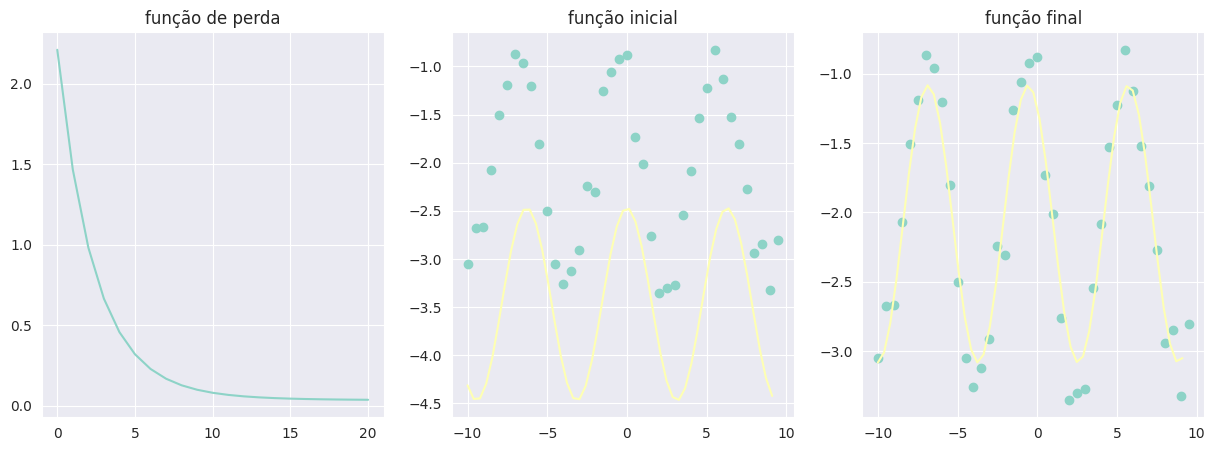

In [7]:
def plota_funcao(x, y, a, b):
    step = (x.max() - x.min()) / 50
    view_x = np.arange(x.min(), x.max(), step)
    with torch.no_grad():
        view_y = calcula_funcao(a, b, torch.from_numpy(view_x)).numpy()
    plt.plot(x, y, 'o')
    plt.plot(view_x, view_y, '-')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("função de perda")
plt.plot([epoch['loss'] for epoch in history], '-')

plt.subplot(1, 3, 2)
plt.title("função inicial")
a, b =  history[0]["params"]
plota_funcao(x, y, a, b)

plt.subplot(1, 3, 3)
plt.title("função final")
a, b =  history[-1]["params"]
plota_funcao(x, y, a, b)


--- 

## Implementação sem pytorch

### Tarefa: Desenhe o grafo computacional resultante do cálculo do erro para um ponto $(x_i, y_i)$, isto é, o valor da expressão dentro do somatório.

*Clique duas vezes para adicionar sua resposta*

### Tarefa: Calcule as derivadas parciais do erro em relação os parâmetros $a$ e $b$.

*Clique duas vezes para adicionar sua resposta*

### Tarefa: Implemente a função dados os valores de a, b e xi:

In [8]:
# resposta
import numpy as np

def calcula_funcao(a, b, xi):
    return np.sin(a+xi)+b

calcula_funcao(2, 3, 3)

np.float64(2.0410757253368614)

### Tarefa: Implemente uma função para calcular o valor da função de perda considerando todos os pontos do dataset e os valores atuais dos coeficientes:

In [9]:
def loss_fn(a, b, x, y):
    loss = 0
    for xi, yi in zip(x, y):
        loss += (yi - calcula_funcao(a,b,xi))**2
    loss /= len(x)
    return loss

### Tarefa: Implemente uma função que calcule os valores das derivadas parciais em relação aos coeficientes para um ponto $(x_i, y_i)$ específico: 

In [12]:
def derivadas_parciais_xi(a, b, xi, yi):
    diff = (-2)*(yi - calcula_funcao(a,b,xi))
    da = diff*(np.cos(a+xi))
    db = diff

    return da, db

### Tarefa: Implemente uma função que calcule as derivadas parciais em relação aos coeficientes para todo o dataset. Como estamos usando o MSE, o gradiente total será a média dos gradientes para cada ponto.

In [13]:
def calcula_gradiente(a, b, x, y):
    grad_a, grad_b = 0, 0
    for xi, yi in zip(x, y):
        res = derivadas_parciais_xi(a,b,xi,yi)
        grad_a += res[0]
        grad_b += res[1]
    grad_a /= len(x)
    grad_b /= len(x)

    return grad_a, grad_b

calcula_gradiente(2, 3, x, y)

(np.float32(-0.123255506), np.float32(10.133331))

### Tarefa: Use as funções para desenvolver uma função que implemente o algoritmo de descida do gradiente. 

In [15]:
def gradient_descent(x, y, n_epochs, lr):
    # inicializa coeficientes com valores aleatórios
    a = np.random.uniform(-5, 5)
    b = np.random.uniform(-5, 5)

    # salva o valor da loss e dos parâmetros antes do treinamento
    history = [{"loss": loss_fn(a, b, x, y), "params": [a, b]}]

    # repete por algumas épocas
    for _ in range(n_epochs):

        # calcula a derivada parcial do erro em relação aos parâmetros
        grad_a, grad_b = calcula_gradiente(a, b, x, y)

        # atualiza os parâmetros usando descida do gradiente
        a -= lr*grad_a
        b -= lr*grad_b

        # salva o valor da loss e os valores dos coeficientes nesta época
        loss = loss_fn(a, b, x, y)
        history.append({"loss": loss, "params": [a, b]})

    return history

history = gradient_descent(x, y, 20, 1e-1)
for epoch in history:
    print(epoch['loss'])

14.0208435
9.060899
5.868783
3.813659
2.4895015
1.6351807
1.082909
0.7249559
0.49217147
0.34016153
0.24040577
0.17455871
0.13079938
0.101493396
0.0816966
0.06819515
0.058891684
0.05241058
0.047844093
0.04458954
0.042243373


Mostra a evolução da perda e da função antes e depois do treinamento.

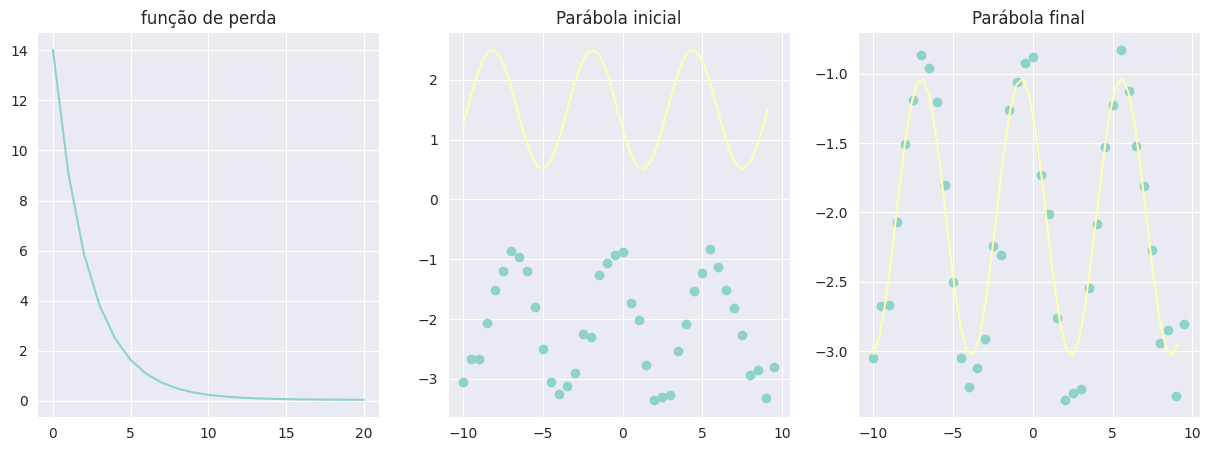

In [16]:
def plota_parabola(x, y, a, b):
    step = (x.max() - x.min()) / 50
    view_x = np.arange(x.min(), x.max(), step)
    view_y = [calcula_funcao(a, b, xi) for xi in view_x]
    plt.plot(x, y, 'o')
    plt.plot(view_x, view_y, '-')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("função de perda")
plt.plot([epoch['loss'] for epoch in history], '-')

plt.subplot(1, 3, 2)
plt.title("Parábola inicial")
a, b =  history[0]["params"]
plota_parabola(x, y, a, b)

plt.subplot(1, 3, 3)
plt.title("Parábola final")
a, b =  history[-1]["params"]
plota_parabola(x, y, a, b)
